In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(r'C:\Users\Tharun37\OneDrive\Desktop\ms ml\cleaned-daily-bike-share.csv', delimiter=",", header='infer')
df = pd.DataFrame(data)
print(df.head())

   instant    dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  1/1/2011       1   0     1        0        6           0   
1        2  1/2/2011       1   0     1        0        0           0   
2        3  1/3/2011       1   0     1        0        1           1   
3        4  1/4/2011       1   0     1        0        2           1   
4        5  1/5/2011       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  rentals  
0           2  0.344167  0.363625  0.805833   0.160446      331  
1           2  0.363478  0.353739  0.696087   0.248539      131  
2           1  0.196364  0.189405  0.437273   0.248309      120  
3           1  0.200000  0.212122  0.590435   0.160296      108  
4           1  0.226957  0.229270  0.436957   0.186900       82  


In [5]:
df['day'] = pd.DatetimeIndex(df['dteday']).day
print(df.head())

   instant    dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  1/1/2011       1   0     1        0        6           0   
1        2  1/2/2011       1   0     1        0        0           0   
2        3  1/3/2011       1   0     1        0        1           1   
3        4  1/4/2011       1   0     1        0        2           1   
4        5  1/5/2011       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  rentals  day  
0           2  0.344167  0.363625  0.805833   0.160446      331    1  
1           2  0.363478  0.353739  0.696087   0.248539      131    2  
2           1  0.196364  0.189405  0.437273   0.248309      120    3  
3           1  0.200000  0.212122  0.590435   0.160296      108    4  
4           1  0.226957  0.229270  0.436957   0.186900       82    5  


120


C:\Users\Tharun37\AppData\Local\Temp\ipykernel_56656\1927054483.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


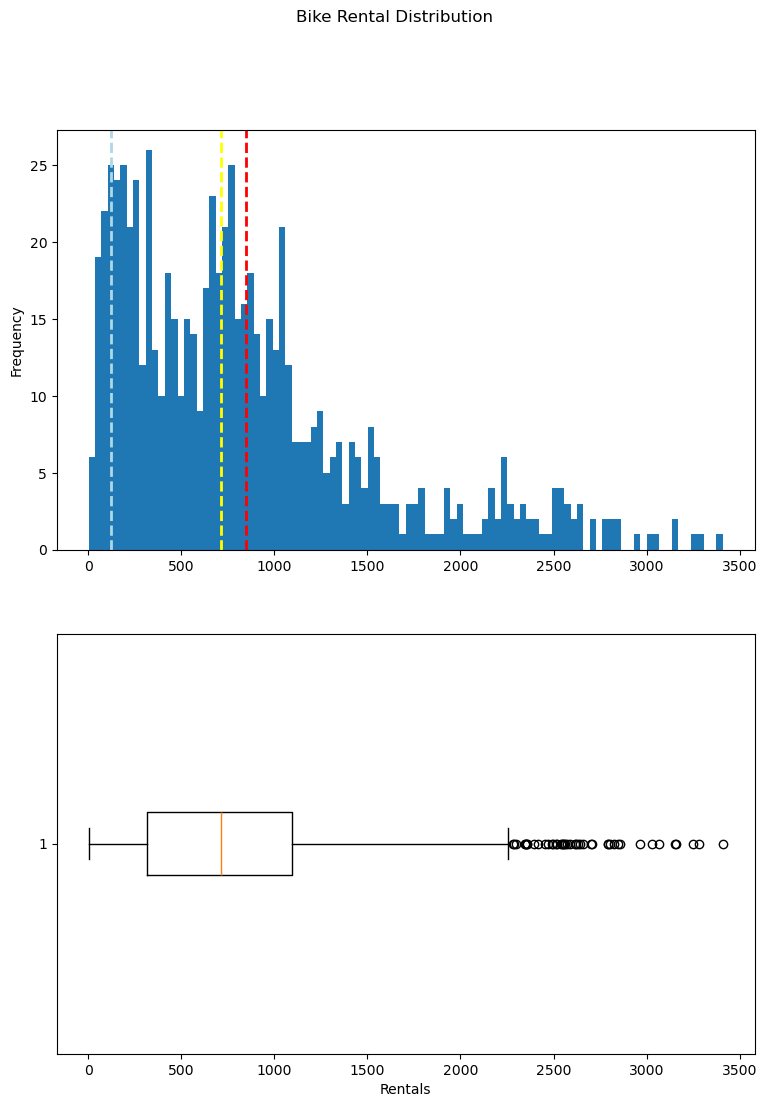

In [6]:
label = df['rentals']
print(label.mode()[0])
fig, ax = plt.subplots(2, 1, figsize = (9,12))
ax[0].hist(label, bins=100)
ax[0].set_ylabel('Frequency')
ax[0].axvline(label.mean(), color = 'red', linestyle = '--', linewidth = 2)
ax[0].axvline(label.median(), color = 'yellow', linestyle = '--', linewidth = 2)
ax[0].axvline(label.mode()[0], color = 'lightblue', linestyle = '--', linewidth = 2)

ax[1].boxplot(label, vert = False)
ax[1].set_xlabel("Rentals")

fig.suptitle("Bike Rental Distribution")
fig.show()

In [7]:
numeric_col = ['temp', 'atemp', 'hum', 'windspeed']
print(df[numeric_col + ['rentals']].describe())

             temp       atemp         hum   windspeed      rentals
count  731.000000  731.000000  731.000000  731.000000   731.000000
mean     0.495385    0.474354    0.627894    0.190486   848.176471
std      0.183051    0.162961    0.142429    0.077498   686.622488
min      0.059130    0.079070    0.000000    0.022392     2.000000
25%      0.337083    0.337842    0.520000    0.134950   315.500000
50%      0.498333    0.486733    0.626667    0.180975   713.000000
75%      0.655417    0.608602    0.730209    0.233214  1096.000000
max      0.861667    0.840896    0.972500    0.507463  3410.000000


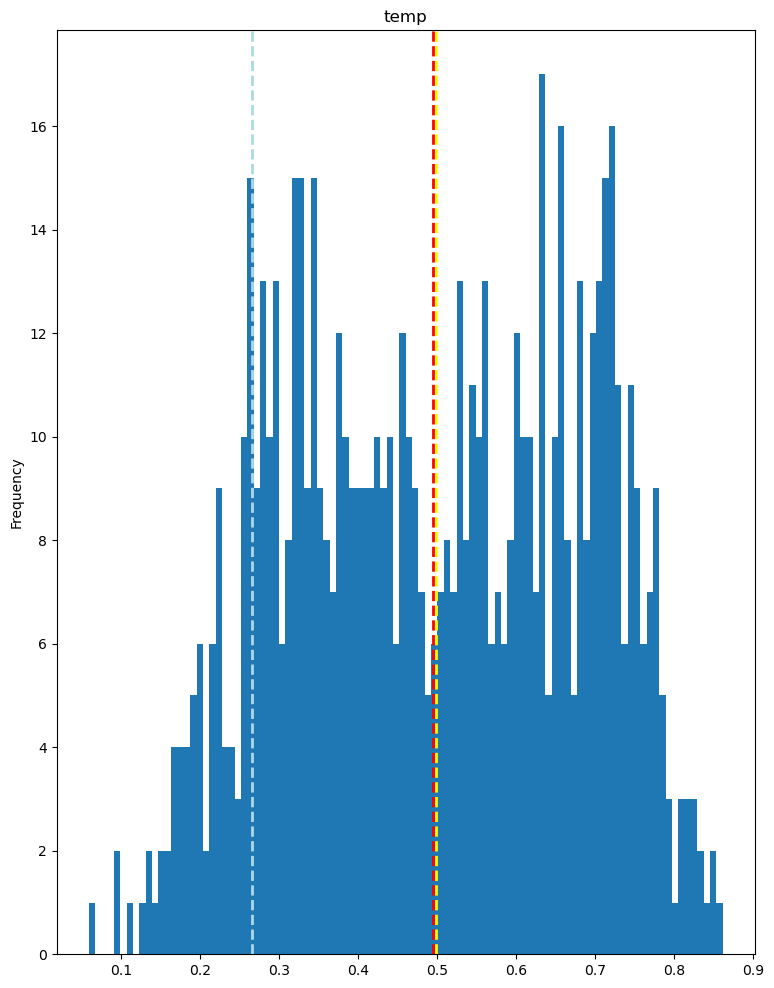

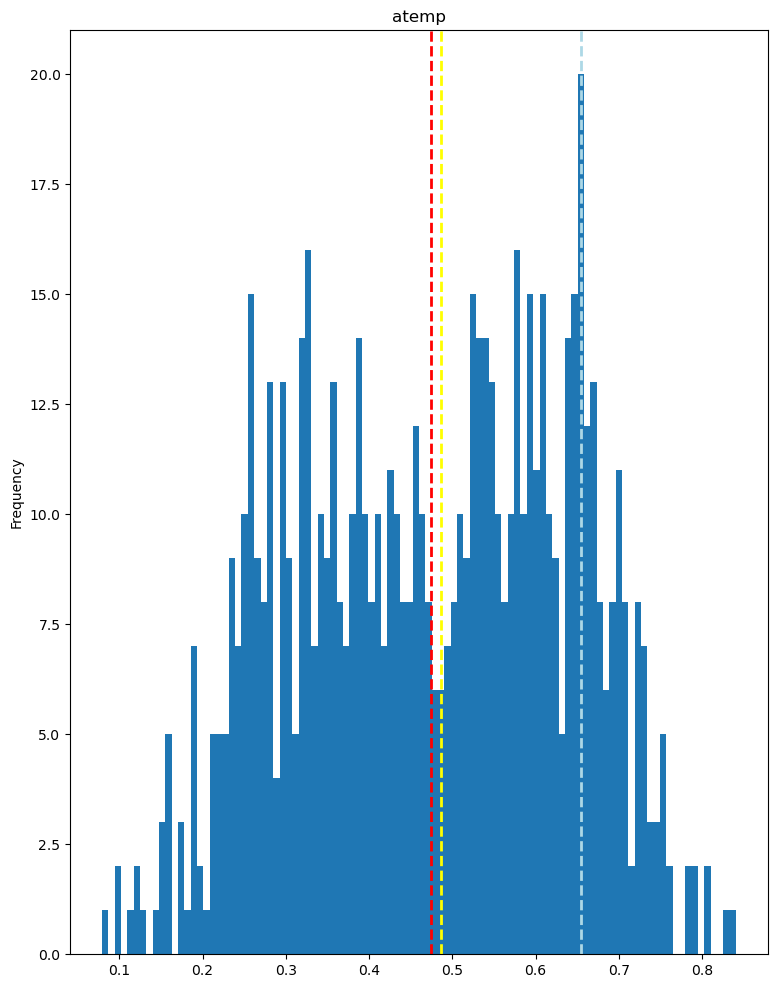

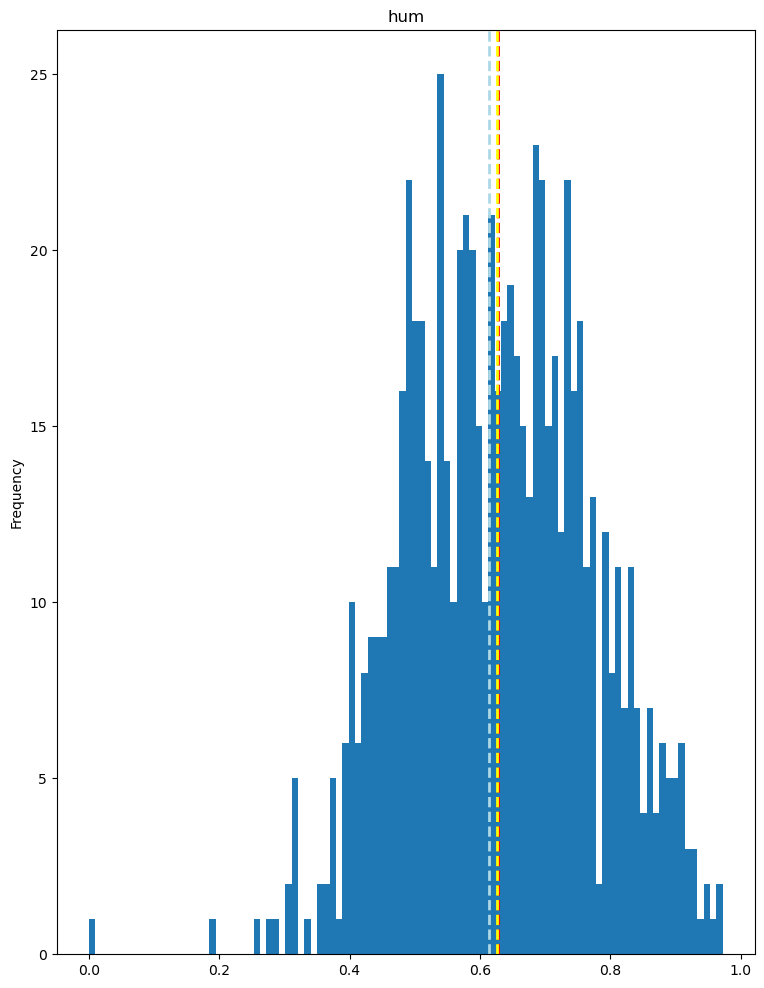

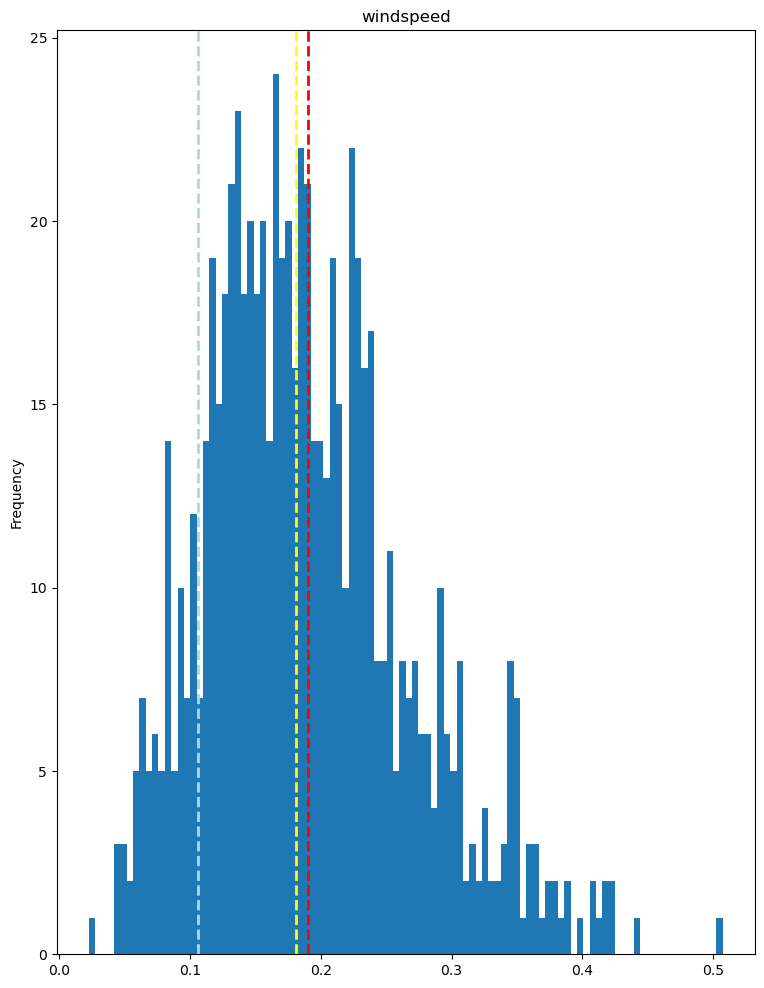

In [8]:
for col in numeric_col:
    fig = plt.figure(figsize = (9,12))
    ax = fig.gca()
    feature = df[col]
    feature.plot.hist(bins=100, ax=ax)
    ax.axvline(feature.mean(), color = 'red', linestyle = '--', linewidth = 2)
    ax.axvline(feature.median(), color = 'yellow', linestyle = '--', linewidth = 2)
    ax.axvline(feature.mode()[0], color = 'lightblue', linestyle = '--', linewidth = 2)
    ax.set_title(col)
plt.show()

In [9]:
print(df.columns.difference(numeric_col))

Index(['day', 'dteday', 'holiday', 'instant', 'mnth', 'rentals', 'season',
       'weathersit', 'weekday', 'workingday', 'yr'],
      dtype='object')


In [10]:
print(df.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'rentals', 'day'],
      dtype='object')


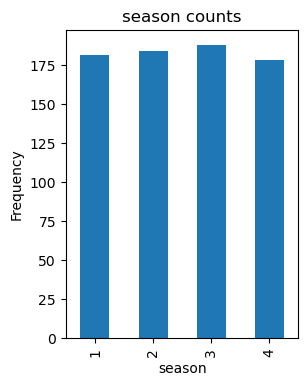

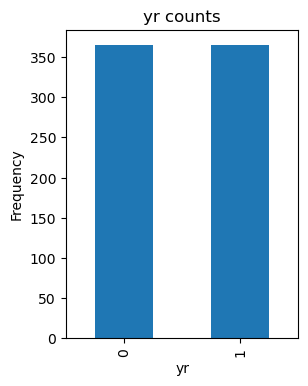

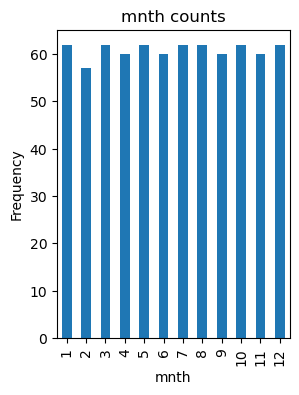

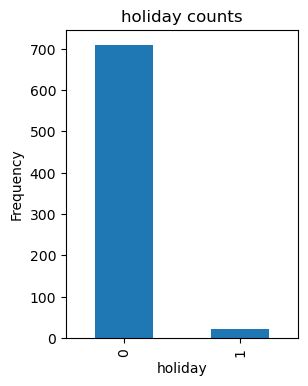

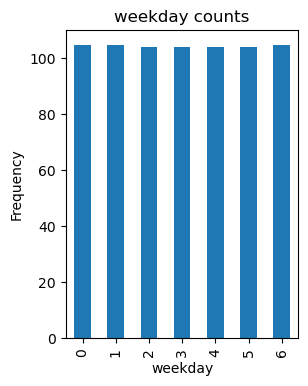

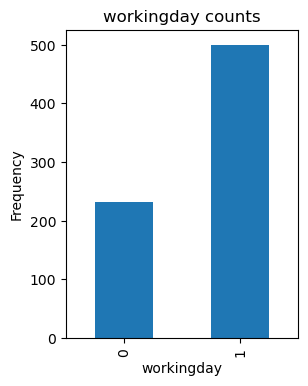

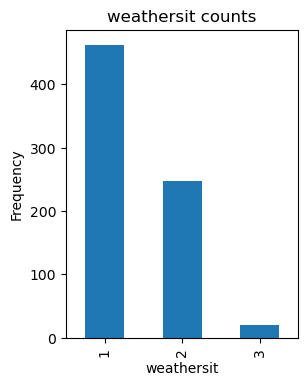

In [11]:
categorical_col = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_col:
    count = df[col].value_counts().sort_index()
    fig = plt.figure(figsize = (3,4))
    ax = fig.gca()
    count.plot.bar(ax = ax)
    ax.set_title(col+' counts')
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.show()

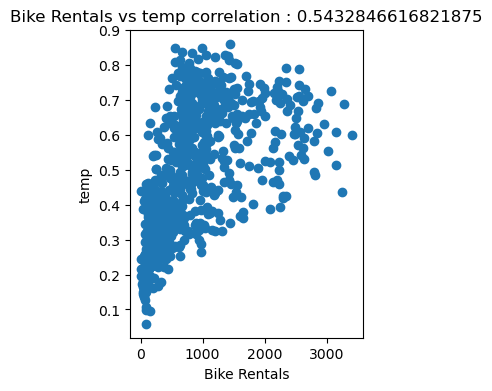

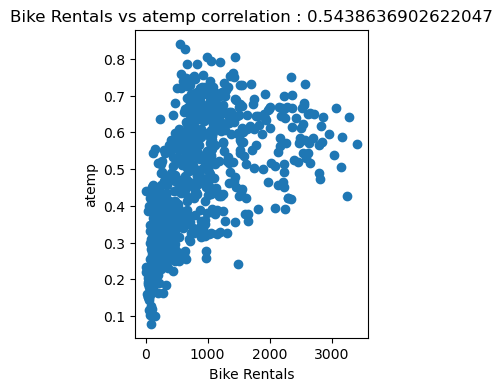

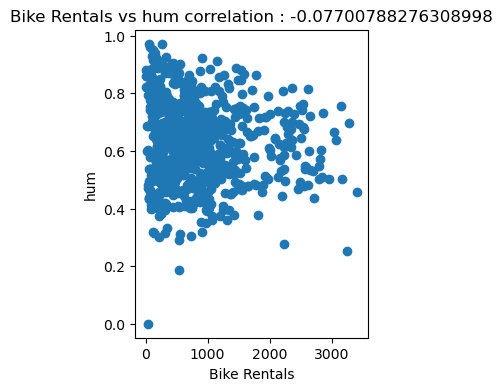

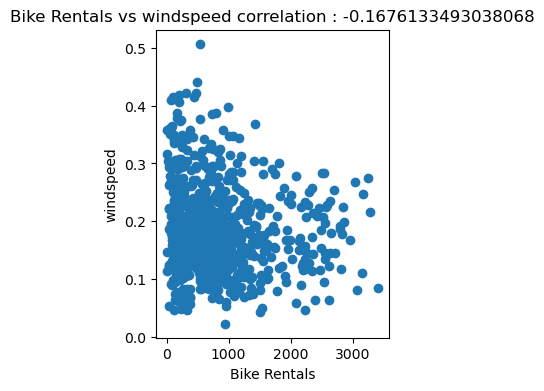

In [18]:
for col in numeric_col:
    fig = plt.figure(figsize=(3,4))
    ax = fig.gca()
    label = df['rentals']
    feature = df[col]
    correlation = feature.corr(label)
    ax.scatter(x = label, y = feature)
    ax.set_xlabel("Bike Rentals")
    ax.set_ylabel(col)
    ax.set_title("Bike Rentals vs " + col + " correlation : " + str(correlation))
plt.show()

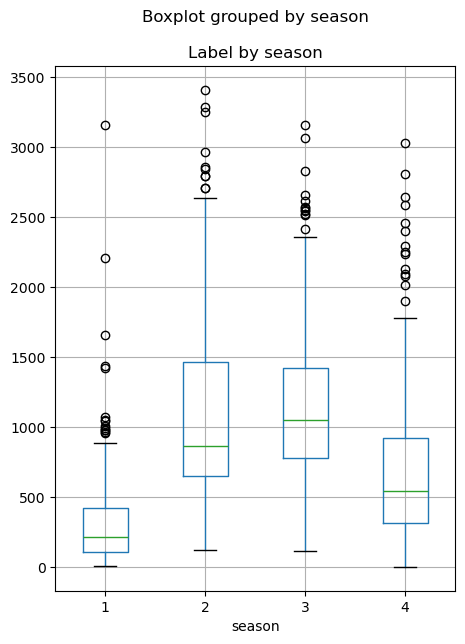

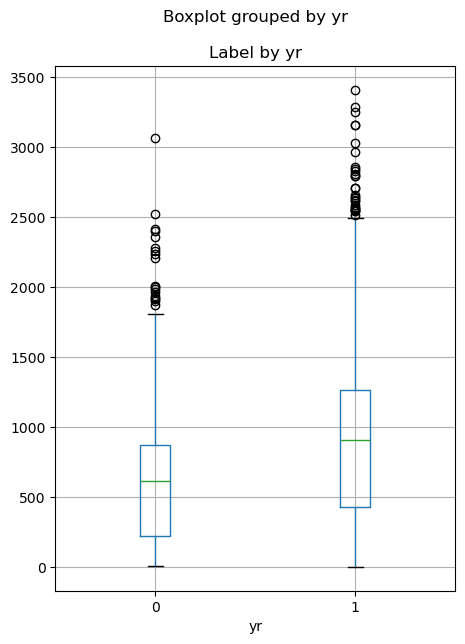

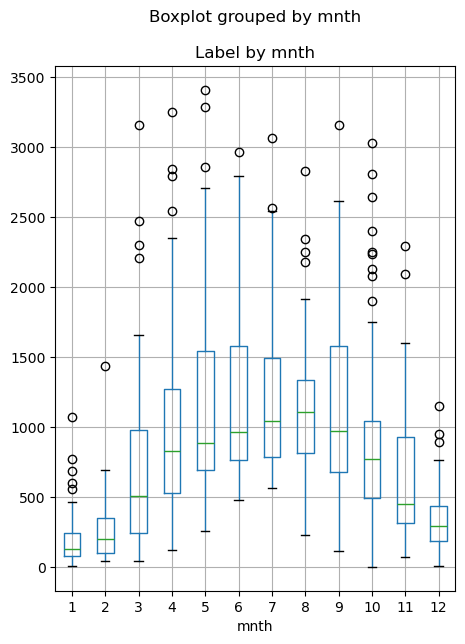

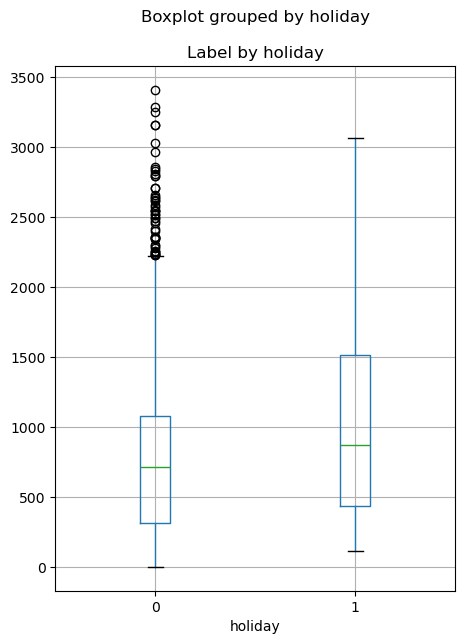

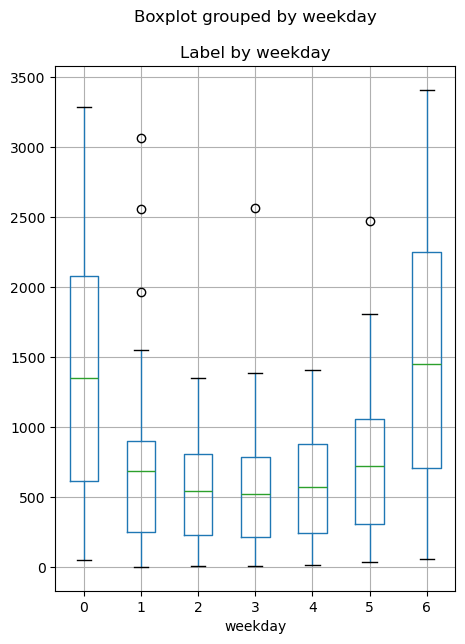

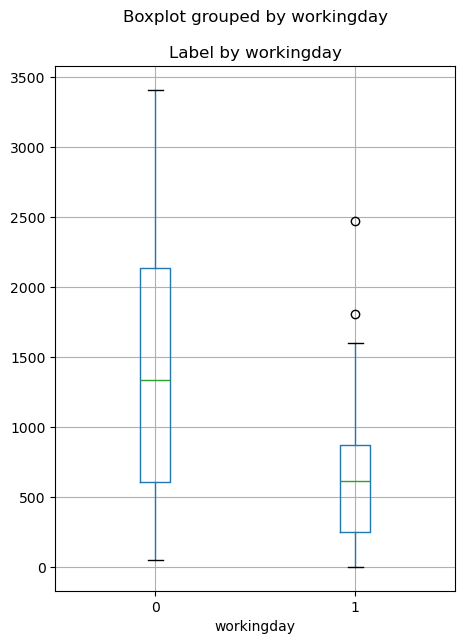

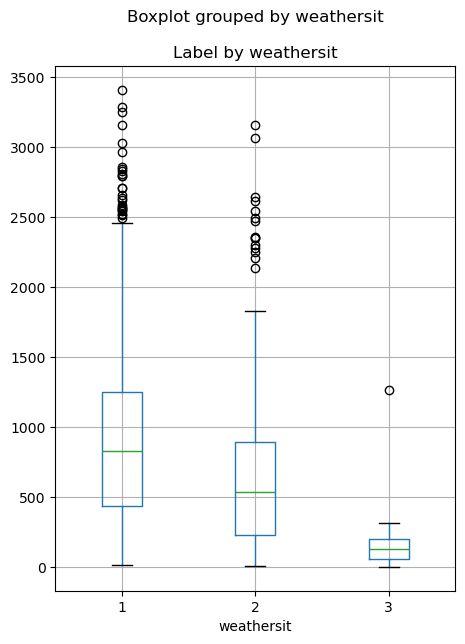

In [12]:
for col in categorical_col:
    fig = plt.figure(figsize = (5,7))
    ax = fig.gca()
    df.boxplot(column = 'rentals', by = col, ax = ax)
    ax.set_title("Label by " + col)
plt.show()

In [21]:
print(df.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'rentals', 'day'],
      dtype='object')


In [19]:
from sklearn.model_selection import train_test_split
x, y= df[['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']].values, df['rentals'].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
print ('Training Set: %d rows\nTest Set: %d rows' % (x_train.shape[0], x_test.shape[0]))

Training Set: 584 rows
Test Set: 147 rows


In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(x_train, y_train)
print(model)

LinearRegression()


In [20]:
predictions = model.predict(x_test)
np.set_printoptions(suppress = True)
print("Predicted values : ", np.round(predictions)[:10])
print("Actual values : ", y_test[:10])

Predicted values :  [1794. 1062.  868. -174.  446.  208.  342.  692. 1622. -128.]
Actual values :  [2418  754  222   47  244  145  240  555 3252   38]


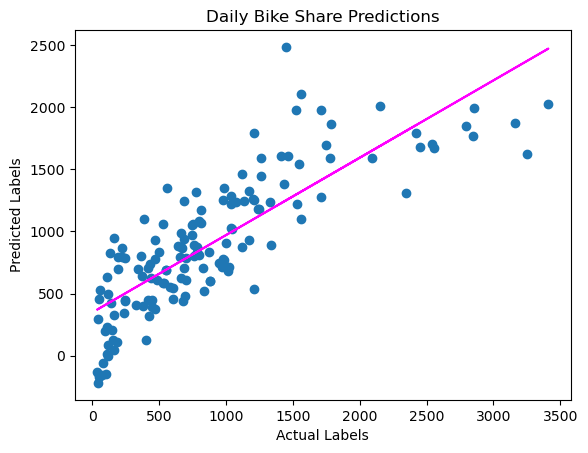

In [21]:
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, predictions)
print("MSE : ",mse)
rmse = np.sqrt(mse)
print("RMSE : ", rmse)
r2 = r2_score(y_test, predictions)
print("R2 score : ",r2)

MSE :  176474.93055306553
RMSE :  420.0891935685391
R2 score :  0.6660216206009655


In [15]:
from sklearn.ensemble import GradientBoostingRegressor
model1 = GradientBoostingRegressor().fit(x_train,  y_train)
print(model1,'\n')

GradientBoostingRegressor() 



In [23]:
predictions_gbr = model1.predict(x_test)
mse_gbr = mean_squared_error(y_test, predictions_gbr)
print("MSE : ",mse_gbr)
rmse_gbr = np.sqrt(mse_gbr)
print("RMSE : ",rmse_gbr)
r2_gbr = r2_score(y_test, predictions_gbr)
print("R2 Score : ", r2_gbr)

MSE :  76085.50335239586
RMSE :  275.83600807798075
R2 Score :  0.8560083688614798


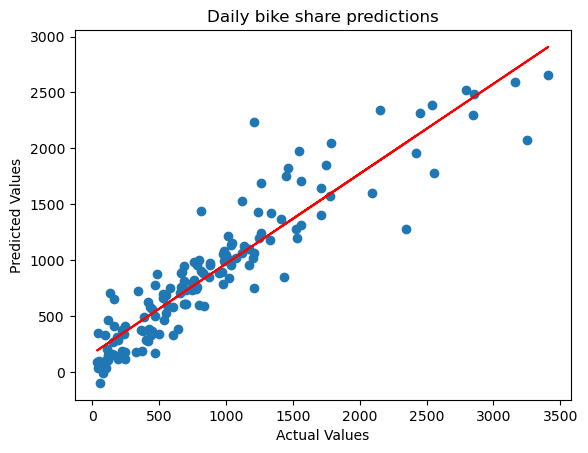

In [25]:
plt.scatter(y_test, predictions_gbr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Daily bike share predictions")

u = np.polyfit(y_test, predictions_gbr, 1)
h = np.poly1d(u)

plt.plot(y_test, h(y_test), color = 'red')
plt.show()